# Data Processing and Preparation

This notebook focuses on Xinran's data-processing part of the Spotify genre classification project, including:

- Data Understanding
- Data Cleaning
- Data Leakage Analysis
- Exploratory Data Analysis
- Feature Selection
- Data Preparation

## 1. Data Understanding

First, we load the dataset and check its basic structure. This helps us understand the size of the dataset, the available columns, the data types, and the target variable for classification.


In [1]:
from pathlib import Path

import pandas as pd

data_path = Path("../dataset/dataset.csv")
if not data_path.exists():
    data_path = Path("dataset/dataset.csv")

df = pd.read_csv(data_path)


In [2]:
df.shape


(114000, 21)

The dataset has 114,000 rows and 21 columns. Each row represents one Spotify track entry.


In [3]:
df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

### 1.1 Target Variable and Task Framing

The target variable for the classification task is `track_genre`. The goal is to predict the genre of a song based on Spotify audio features.

This project treats genre prediction as a **single-label multi-class classification** task. Each row has one target label, so the model predicts one main genre label for each row. However, some songs appear under multiple genre labels in the dataset, so the final prediction should be interpreted as the most likely primary genre, not as all possible genres of a song.

In [5]:
target_column = "track_genre"

target_summary = pd.DataFrame({
    "target_column": [target_column],
    "number_of_genres": [df[target_column].nunique()],
    "minimum_rows_per_genre": [df[target_column].value_counts().min()],
    "maximum_rows_per_genre": [df[target_column].value_counts().max()]
})

target_summary

,target_column,number_of_genres,minimum_rows_per_genre,maximum_rows_per_genre
0,track_genre,114,1000,1000


### 1.2 Understanding Column Types

Before cleaning and exploring the data, we separate the columns into simple groups. This helps us understand the role of each column in the dataset.

For the main classification task, we want to test whether Spotify audio features can predict the genre. Therefore, metadata and identity columns such as track ID, artist name, album name, and track name should be treated differently from audio features.

We store related columns in simple Python lists. This keeps the analysis code shorter and easier to read.

In [6]:
metadata_columns = [
    "track_id",
    "artists",
    "album_name",
    "track_name"
]

spotify_audio_features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

index_like_columns = ["Unnamed: 0"]
non_core_audio_columns = ["popularity", "duration_ms", "explicit"]

### 1.3 Column Groups

To make the dataset easier to understand, we separate the columns into four groups.

**1. Metadata and identity columns**

These columns describe the identity or text metadata of the song:

- `track_id`
- `artists`
- `album_name`
- `track_name`

They are useful for understanding the dataset, but they are not the main audio features for the model.

**2. Spotify audio features**

These columns describe musical characteristics of a song:

- `danceability`
- `energy`
- `key`
- `loudness`
- `mode`
- `speechiness`
- `acousticness`
- `instrumentalness`
- `liveness`
- `valence`
- `tempo`
- `time_signature`

These are the main candidate features for genre classification.

**3. Non-core or index-like columns**

- `Unnamed: 0`: index-like column removed during data cleaning
- `popularity`: platform popularity score, not a pure audio feature
- `duration_ms`: track duration
- `explicit`: whether the track has explicit lyrics

These columns are handled during data cleaning and feature selection.

**4. Target column**

- `track_genre`

This is the genre label we want to predict.

At this stage, the column groups clarify which variables are identities, which variables are Spotify audio features, which variables need cleaning decisions, and which column is the target label.

## 2. Data Cleaning

In this step, we check the main data quality issues before modeling. The goal is to keep the cleaning process simple and transparent:

1. remove the unnecessary index-like column `Unnamed: 0`;
2. check missing values;
3. check duplicated rows;
4. check whether numeric features are within reasonable ranges.

### 2.1 Remove Index-like Column

In [7]:
df_clean = df.drop(columns=index_like_columns)

df_clean.shape

(114000, 20)

The column `Unnamed: 0` is an index-like column from the original CSV file. It does not contain useful information for genre prediction, so it is removed.

### 2.2 Missing Values

In [8]:
missing_values = df_clean.isna().sum()
missing_values[missing_values > 0]

artists       1
album_name    1
track_name    1
dtype: int64

Only three metadata fields have missing values: `artists` has 1 missing value, `album_name` has 1 missing value, and `track_name` has 1 missing value. The Spotify audio feature columns and the target column do not have missing values, so no complex missing-value treatment is needed for the main analysis.

### 2.3 Fully Duplicated Rows

In [9]:
duplicate_rows_before = df_clean.duplicated().sum()
duplicate_rows_before

np.int64(450)

In [10]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

df_clean.shape

(113550, 20)

After removing the index-like column, there are 450 fully duplicated rows. These rows contain the same values in all remaining columns, so they do not add new information. We remove them to keep the dataset cleaner.

Duplicated `track_id` values are checked separately in the data leakage analysis because the same song can appear in more than one genre. That is a different and more important leakage issue.

### 2.4 Numeric Range Checks

In [11]:
numeric_columns = spotify_audio_features + ["popularity", "duration_ms"]

df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,113550.0,0.567031,0.173408,0.000,0.45600,0.580000,0.695000,0.985
energy,113550.0,0.642090,0.251052,0.000,0.47300,0.685000,0.854000,1.000
key,113550.0,5.309467,3.560134,0.000,2.00000,5.000000,8.000000,11.000
loudness,113550.0,-8.243419,5.011401,-49.531,-9.99775,-6.997000,-5.001000,4.532
mode,113550.0,0.637860,0.480621,0.000,0.00000,1.000000,1.000000,1.000
speechiness,113550.0,0.084674,0.105761,0.000,0.03590,0.048900,0.084500,0.965
acousticness,113550.0,0.314067,0.331907,0.000,0.01680,0.168000,0.596000,0.996
instrumentalness,113550.0,0.155702,0.309216,0.000,0.00000,0.000041,0.048675,1.000
liveness,113550.0,0.213611,0.190461,0.000,0.09800,0.132000,0.273000,1.000
valence,113550.0,0.474207,0.259204,0.000,0.26000,0.464000,0.683000,0.995


The descriptive statistics give a first overview of the numeric columns. The range check below verifies whether important bounded features stay inside their expected ranges.

In [12]:
range_rules = [
    ("danceability", 0, 1),
    ("energy", 0, 1),
    ("speechiness", 0, 1),
    ("acousticness", 0, 1),
    ("instrumentalness", 0, 1),
    ("liveness", 0, 1),
    ("valence", 0, 1),
    ("popularity", 0, 100),
    ("key", -1, 11),
    ("mode", 0, 1),
    ("time_signature", 0, 7)
]

range_check = []

for column, minimum, maximum in range_rules:
    out_of_range = ((df_clean[column] < minimum) | (df_clean[column] > maximum)).sum()
    range_check.append({
        "column": column,
        "expected_range": f"{minimum} to {maximum}",
        "actual_min": df_clean[column].min(),
        "actual_max": df_clean[column].max(),
        "out_of_range_rows": out_of_range
    })

pd.DataFrame(range_check)

,column,expected_range,actual_min,actual_max,out_of_range_rows
0,danceability,0 to 1,0.0,0.985,0
1,energy,0 to 1,0.0,1.000,0
2,speechiness,0 to 1,0.0,0.965,0
3,acousticness,0 to 1,0.0,0.996,0
4,instrumentalness,0 to 1,0.0,1.000,0
5,liveness,0 to 1,0.0,1.000,0
6,valence,0 to 1,0.0,0.995,0
7,popularity,0 to 100,0.0,100.000,0
8,key,-1 to 11,0.0,11.000,0
9,mode,0 to 1,0.0,1.000,0


In [13]:
time_signature_zero_rows = (df_clean["time_signature"] == 0).sum()

time_signature_zero_summary = pd.DataFrame({
    "time_signature_value": [0],
    "rows": [time_signature_zero_rows],
    "percentage_of_cleaned_data": [round(time_signature_zero_rows / len(df_clean) * 100, 3)]
})

time_signature_zero_summary

,time_signature_value,rows,percentage_of_cleaned_data
0,0,163,0.144


The checked numeric features are within the expected ranges used for this project. One small note is that `time_signature` contains 163 rows with value `0`, which is about 0.144% of the cleaned data. The dataset documentation mainly discusses musical time signatures from 3 to 7, so `0` may represent an unknown or special encoded value.

We keep these rows in this first version because the proportion is very small and the values are already numeric. This is noted as a data limitation rather than treated as a major cleaning problem.

The cleaned dataframe used in the following sections is called `df_clean`.

## 3. Data Leakage Analysis

A key issue in this dataset is that the same Spotify track can appear more than once. In some cases, the same `track_id` is assigned to more than one genre.

This section is placed before Data Preparation because the leakage findings determine the train-test split strategy.

This matters because a normal random `train_test_split` can put the same song into both the training set and the test set. If that happens, the test set is no longer fully independent, and model performance can become biased and unreliable.

In this section, we check four related issues:

1. whether `track_id` values are repeated;
2. whether the same track can have multiple genre labels;
3. whether some genre pairs share many identical tracks;
4. whether a normal random split creates train/test overlap by `track_id`.

### 3.1 Repeated Track IDs

First, we check whether the number of rows is larger than the number of unique `track_id` values. If this happens, it means some songs appear more than once in the cleaned dataset.

In [14]:
track_id_summary = pd.DataFrame({
    "rows_after_cleaning": [len(df_clean)],
    "unique_track_id": [df_clean["track_id"].nunique()],
    "rows_with_repeated_track_id": [df_clean.duplicated("track_id").sum()],
    "track_ids_appearing_more_than_once": [(df_clean["track_id"].value_counts() > 1).sum()]
})

track_id_summary

,rows_after_cleaning,unique_track_id,rows_with_repeated_track_id,track_ids_appearing_more_than_once
0,113550,89741,23809,16299


The number of unique `track_id` values is smaller than the number of rows, so some songs appear multiple times in the dataset. This means we cannot treat every row as a completely independent song.

### 3.2 Tracks with Multiple Genre Labels

This step checks whether the same `track_id` can be linked to more than one `track_genre`. This is important because repeated songs are not always simple duplicate rows.

In [15]:
genres_per_track = df_clean.groupby("track_id")[target_column].nunique()

multi_genre_summary = pd.DataFrame({
    "track_ids_with_more_than_one_genre": [(genres_per_track > 1).sum()],
    "maximum_genres_for_one_track": [genres_per_track.max()]
})

multi_genre_summary

,track_ids_with_more_than_one_genre,maximum_genres_for_one_track
0,16299,9


Some tracks appear in more than one genre. This means the same song can have multiple labels in the dataset, which makes the classification problem more difficult and creates a risk for data leakage if we split rows randomly.

In [16]:
example_track_ids = genres_per_track[genres_per_track > 1].head(5).index

multi_genre_examples = df_clean.loc[
    df_clean["track_id"].isin(example_track_ids),
    ["track_id", "artists", "track_name", target_column]
].sort_values("track_id")

multi_genre_examples

,track_id,artists,track_name,track_genre
15008,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,Better,chill
102770,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,Better,soul
85238,001YQlnDSduXd5LgBd66gT,Soda Stereo,El Tiempo Es Dinero - Remasterizado 2007,punk-rock
99979,001YQlnDSduXd5LgBd66gT,Soda Stereo,El Tiempo Es Dinero - Remasterizado 2007,ska
2105,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,alt-rock
3255,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,alternative
91460,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,rock
33024,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Lovemark,emo
93801,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Lovemark,sad
34983,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,Agora Estou Sofrendo - Ao Vivo,forro


The examples above show why duplicated `track_id` values need special attention. The same song can be linked to different genre labels, so the split strategy must keep all rows of the same song together.

### 3.3 Genre Overlap Between Genre Labels

Because some songs appear under more than one genre label, we also check whether some genre pairs share many identical `track_id` values.

This is not the same as feature correlation. Here, we are checking label overlap: if two genres contain many of the same songs, they may be naturally harder for a model to separate.

In [17]:
genre_track_sets = df_clean.groupby(target_column)["track_id"].apply(lambda track_ids: set(track_ids))
genre_names = genre_track_sets.index.tolist()

genre_overlap_rows = []

for first_index in range(len(genre_names)):
    for second_index in range(first_index + 1, len(genre_names)):
        first_genre = genre_names[first_index]
        second_genre = genre_names[second_index]
        first_tracks = genre_track_sets.loc[first_genre]
        second_tracks = genre_track_sets.loc[second_genre]
        shared_track_ids = first_tracks.intersection(second_tracks)
        shared_count = len(shared_track_ids)

        if shared_count > 0:
            smaller_genre_size = min(len(first_tracks), len(second_tracks))
            total_unique_tracks = len(first_tracks.union(second_tracks))

            genre_overlap_rows.append({
                "genre_1": first_genre,
                "genre_2": second_genre,
                "shared_track_ids": shared_count,
                "overlap_percent_of_smaller_genre": round(shared_count / smaller_genre_size * 100, 1),
                "jaccard_similarity": round(shared_count / total_unique_tracks, 3)
            })

genre_overlap_table = (
    pd.DataFrame(genre_overlap_rows)
    .sort_values(["shared_track_ids", "jaccard_similarity"], ascending=False)
    .head(10)
)

genre_overlap_table

,genre_1,genre_2,shared_track_ids,overlap_percent_of_smaller_genre,jaccard_similarity
1107,singer-songwriter,songwriter,1000,100.0,1.000
1082,reggae,reggaeton,804,80.4,0.672
955,latino,reggaeton,738,74.3,0.588
448,dub,dubstep,727,72.8,0.572
1052,punk,punk-rock,628,62.9,0.458
476,edm,house,624,62.8,0.456
954,latino,reggae,616,62.0,0.447
24,alt-rock,alternative,592,59.3,0.421
940,latin,latino,588,59.4,0.422
821,indie,indie-pop,579,58.1,0.408


The table shows that some genre pairs share many of the same songs. For example, highly overlapping genre pairs may represent very similar labels or nearly duplicated label groups.

This result does not mean that genre similarity alone causes data leakage. The leakage risk comes from the same `track_id` appearing on both sides of a train/test split. However, strong genre overlap shows that multi-genre repeated tracks are common, so using `track_id` as a group variable is important.

This supports two points:

1. Genre classification is naturally difficult because some genre labels overlap strongly.
2. The train/test split should keep all rows of the same `track_id` together, so the same song cannot appear in both training and test data.

Grouped splitting prevents identical tracks from appearing in both train and test sets, but it does not remove the label ambiguity caused by some tracks having multiple genre labels. This remains a limitation of the dataset.

### 3.4 Leakage from a Normal Random Split

Finally, we test what happens if we use a normal random split. This split is done by row, so it can separate rows with the same `track_id` into different datasets.

This example is only used to demonstrate row-level leakage. Stratifying by `track_genre` would help class balance, but it would not solve the `track_id` overlap problem.

In [18]:
from sklearn.model_selection import train_test_split

normal_train_index, normal_test_index = train_test_split(
    df_clean.index,
    test_size=0.2,
    random_state=42
)

train_track_ids = set(df_clean.loc[normal_train_index, "track_id"])
test_track_ids = set(df_clean.loc[normal_test_index, "track_id"])
overlapping_track_ids = train_track_ids.intersection(test_track_ids)

normal_split_check = pd.DataFrame({
    "train_test_split_method": ["normal random split"],
    "overlapping_track_ids": [len(overlapping_track_ids)]
})

normal_split_check

,train_test_split_method,overlapping_track_ids
0,normal random split,6325


The normal random split creates overlapping `track_id` values between training and test data. This is data leakage because the same song can appear on both sides of the split.

This does not mean every leaked row is predicted correctly. If the same song has conflicting genre labels, the result can also become confusing. The main problem is that the test set is no longer independent, so the evaluation is biased and unreliable.

Section 6 uses `GroupShuffleSplit` with `track_id` as the group variable. This keeps all rows of the same song either in the training set or in the test set, but not both.

## 4. Exploratory Data Analysis

In this section, we explore the cleaned dataset to understand the target distribution, audio feature distributions, feature correlations, and selected genre-level audio patterns.

The EDA is descriptive and is not used to tune model hyperparameters. The final feature set is based on the project scope rather than test-set performance.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titleweight"] = "bold"

# Shared brighter soft palette for Section 4.1 and Section 4.2.
distribution_palette = {
    "danceability": "#7FAAD4",
    "valence": "#76BDB4",
    "tempo": "#9BCB7D",
    "energy": "#E4B756",
    "loudness": "#E69A6D",
    "acousticness": "#D98C8C",
    "speechiness": "#C185B7",
    "instrumentalness": "#A08BD5",
    "liveness": "#7F9FD4",
    "key": "#6FB4CC",
    "mode": "#D3A85B",
    "time_signature": "#93C178"
}

largest_group_color = "#E4B756"
smallest_group_color = "#6FB4CC"

### 4.1 Genre Distribution After Cleaning

First, we check whether the target variable `track_genre` is still relatively balanced after removing duplicated rows. Because the dataset has 114 genres, showing all genre names in one plot would be difficult to read. Instead, we compare the 10 largest and 10 smallest genre groups.

In the bar chart, the x-axis shows the number of tracks and the y-axis shows the genre name. The two colors separate the largest genre groups from the smallest genre groups.

In [20]:
genre_counts = df_clean[target_column].value_counts()

genre_count_summary = pd.DataFrame({
    "number_of_genres": [genre_counts.size],
    "minimum_rows_per_genre": [genre_counts.min()],
    "maximum_rows_per_genre": [genre_counts.max()],
    "average_rows_per_genre": [round(genre_counts.mean(), 2)]
})

genre_count_summary

,number_of_genres,minimum_rows_per_genre,maximum_rows_per_genre,average_rows_per_genre
0,114,904,1000,996.05


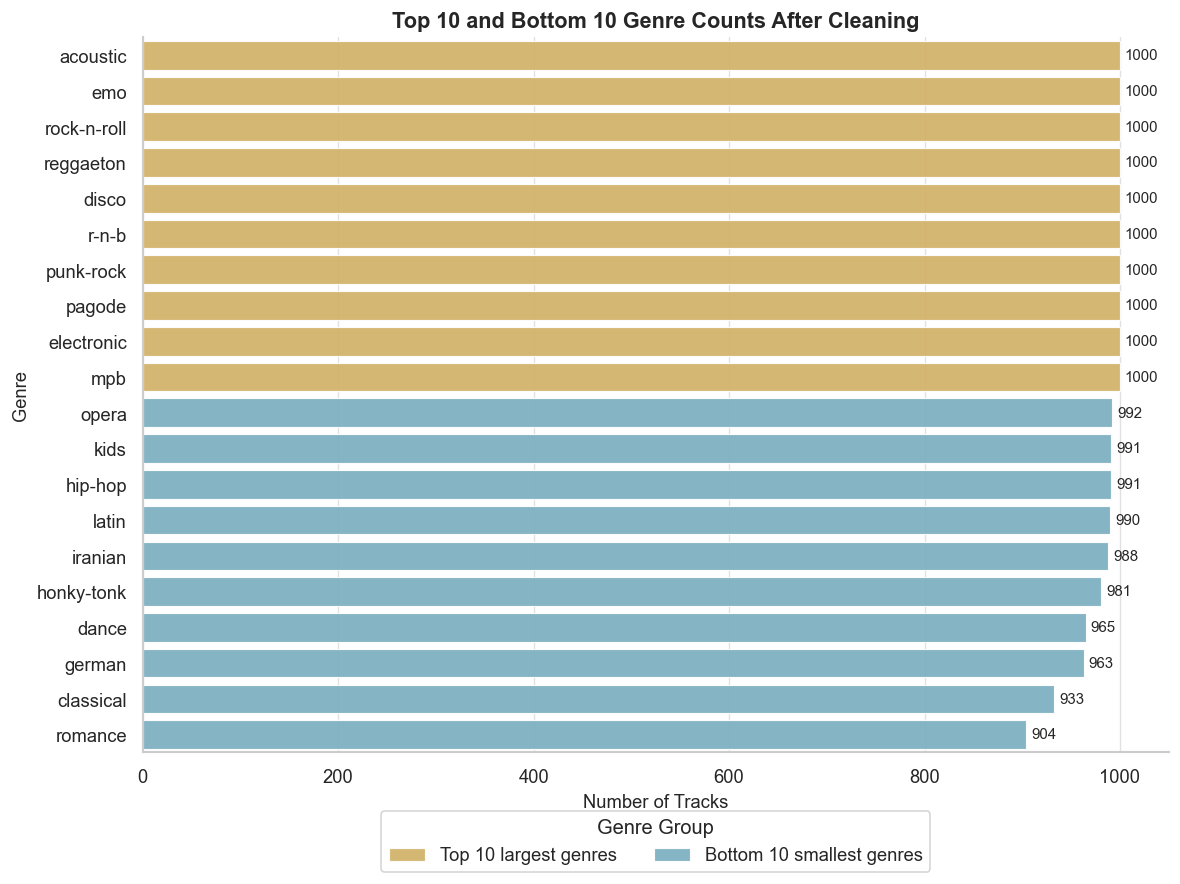

In [21]:
top_genres = genre_counts.head(10)
bottom_genres = genre_counts.tail(10)
genres_to_plot = pd.concat([top_genres, bottom_genres])

genre_plot_data = pd.DataFrame({
    "genre": genres_to_plot.index,
    "number_of_tracks": genres_to_plot.values,
    "group": ["Top 10 largest genres"] * len(top_genres) + ["Bottom 10 smallest genres"] * len(bottom_genres)
})

fig, ax = plt.subplots(figsize=(10, 7.5))
sns.barplot(
    data=genre_plot_data,
    x="number_of_tracks",
    y="genre",
    hue="group",
    dodge=False,
    palette={
        "Top 10 largest genres": largest_group_color,
        "Bottom 10 smallest genres": smallest_group_color
    },
    alpha=0.92,
    edgecolor="white",
    linewidth=0.7,
    ax=ax
)

ax.set_title("Top 10 and Bottom 10 Genre Counts After Cleaning")
ax.set_xlabel("Number of Tracks")
ax.set_ylabel("Genre")
ax.set_xlim(0, 1050)
ax.grid(axis="x", color="#B8B8B8", alpha=0.42, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Genre Group", loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2)

for index, value in enumerate(genres_to_plot.values):
    ax.text(value + 5, index, str(value), va="center", fontsize=9)

plt.tight_layout()
plt.show()

After cleaning, the dataset remains relatively balanced. Most genres still have close to 1,000 tracks, although a few genres have fewer rows because duplicated rows were removed. Within this cleaned dataset, no genre dominates the target distribution.

### 4.2 Audio Feature Distributions

This section examines the distributions of the Spotify audio features before modeling.

Because the audio features have different variable types, we use different plot types:

- **Continuous audio features** are shown with histograms.
- **Discrete audio features** such as `key`, `mode`, and `time_signature` are shown with lollipop charts.

The plots use the brighter soft color palette defined at the start of the EDA section. Each feature has its own color, but the colors stay close in saturation and tone so the section remains visually consistent without looking dark or overly colorful.

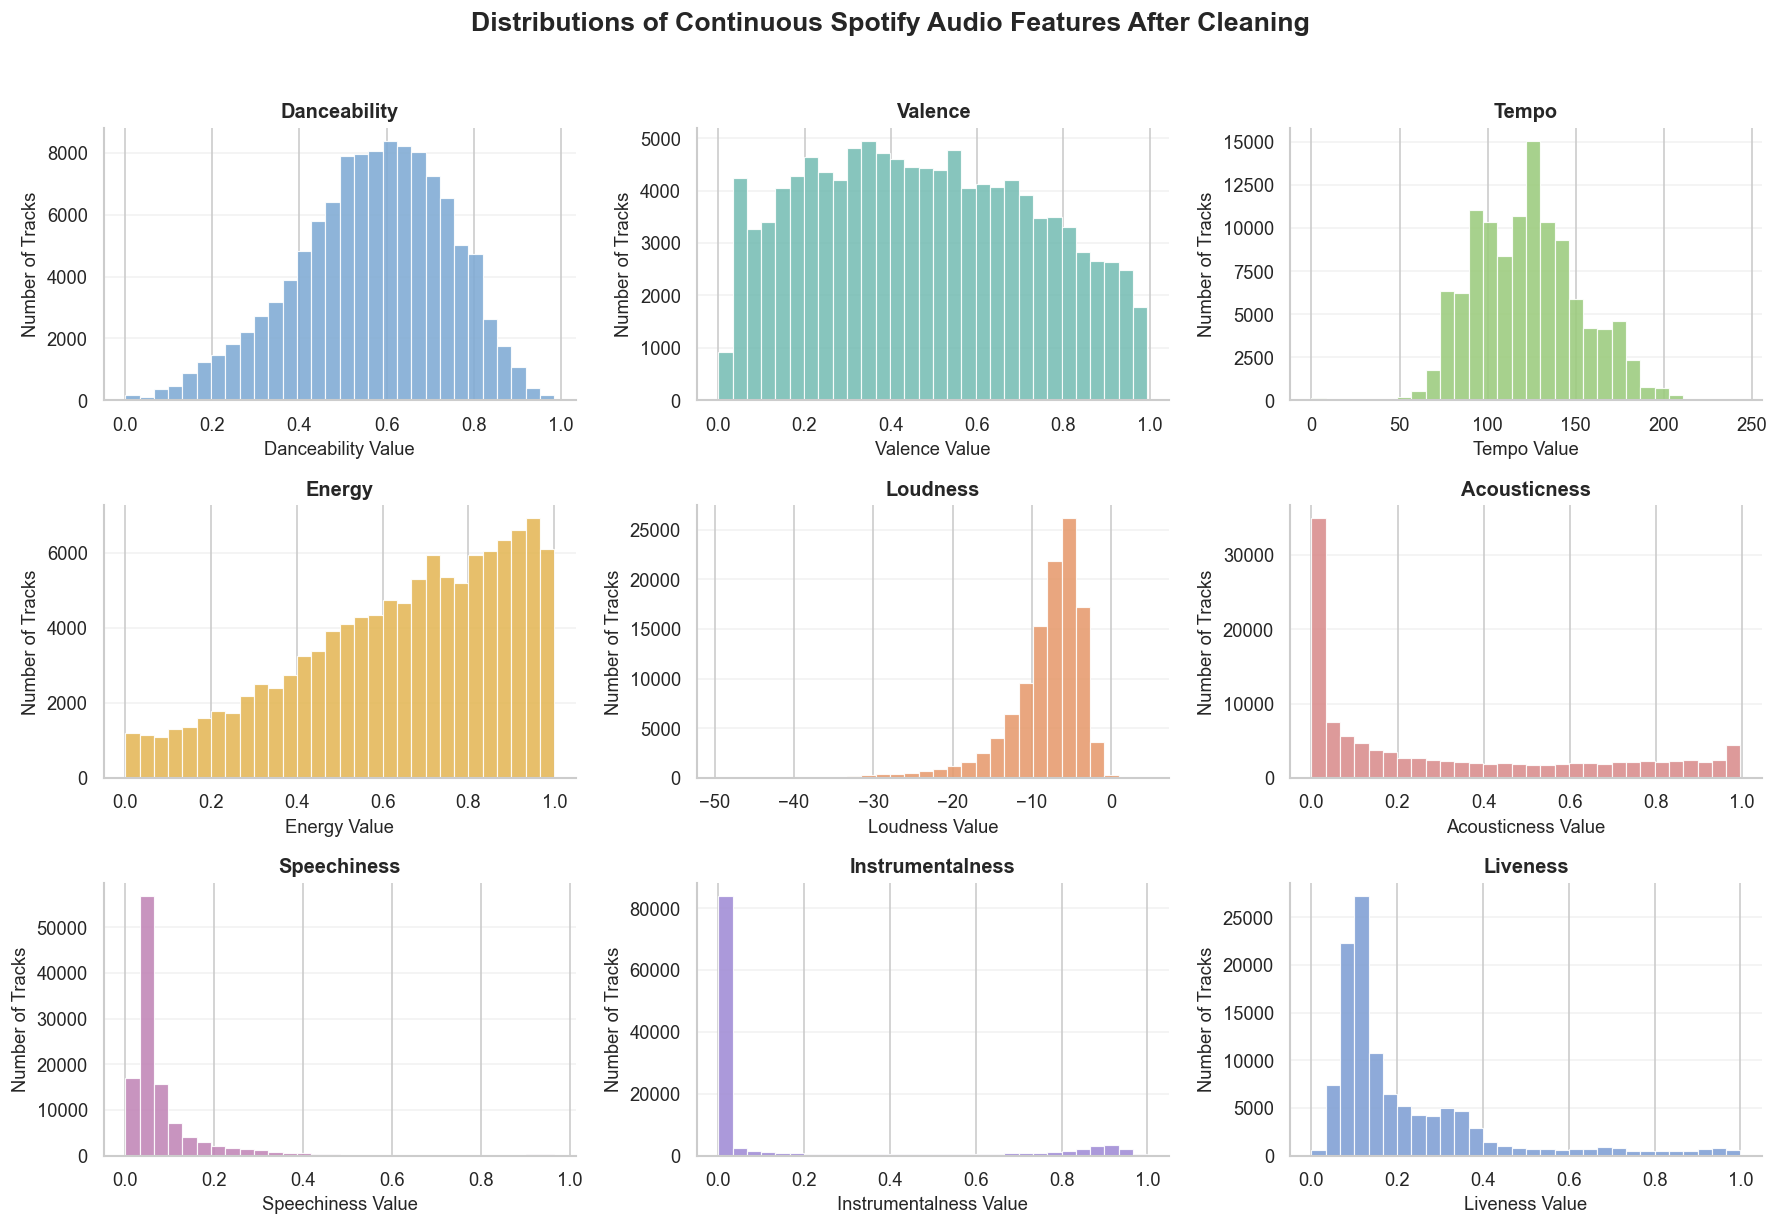

In [22]:
continuous_audio_features = [
    "danceability",
    "valence",
    "tempo",
    "energy",
    "loudness",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for index, feature in enumerate(continuous_audio_features):
    ax = axes[index]
    ax.hist(
        df_clean[feature].dropna(),
        bins=30,
        color=distribution_palette[feature],
        alpha=0.88,
        edgecolor="white",
        linewidth=0.7
    )
    feature_title = feature.replace("_", " ").title()
    ax.set_title(feature_title, fontsize=12)
    ax.set_xlabel(f"{feature_title} Value")
    ax.set_ylabel("Number of Tracks")
    ax.grid(axis="y", alpha=0.24)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Distributions of Continuous Spotify Audio Features After Cleaning",
    fontsize=16,
    fontweight="bold",
    y=1.02
)
plt.tight_layout()
plt.show()

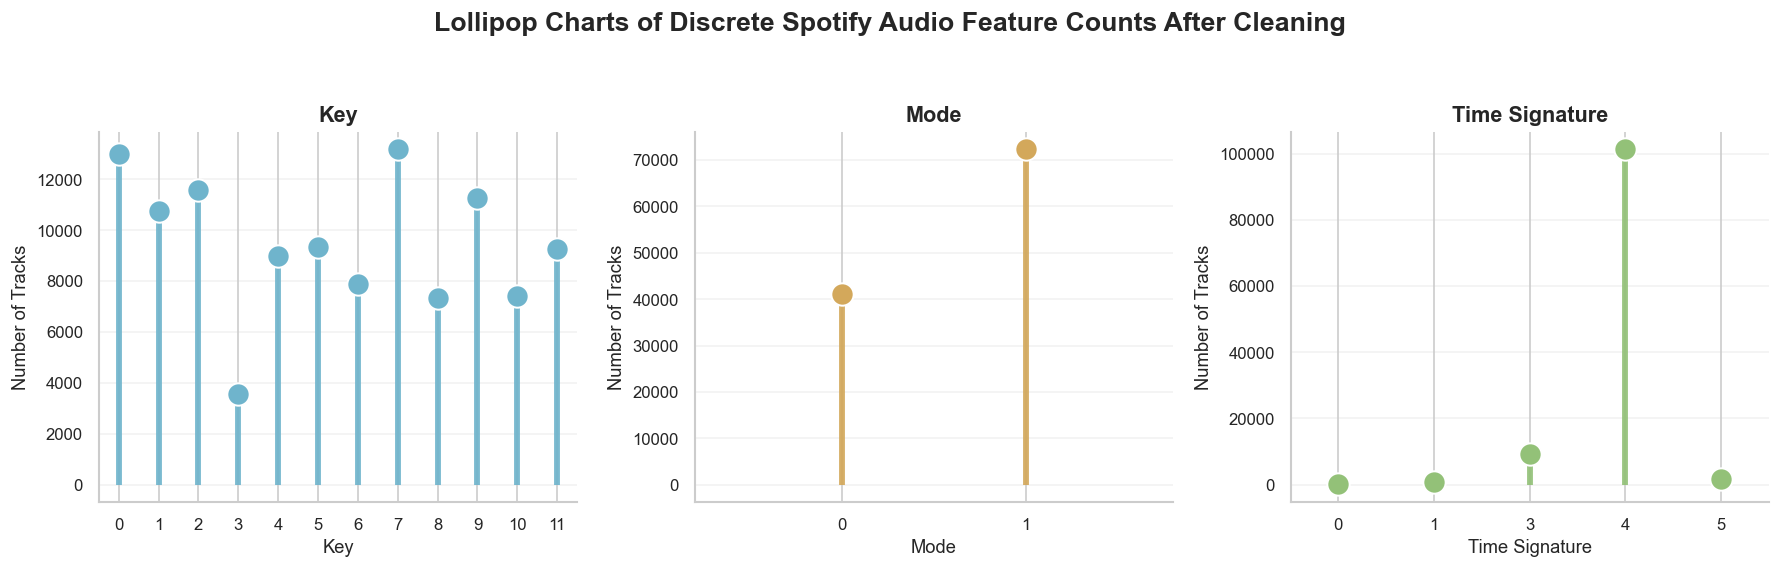

In [23]:
discrete_audio_features = ["key", "mode", "time_signature"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for index, feature in enumerate(discrete_audio_features):
    ax = axes[index]
    value_counts = df_clean[feature].value_counts().sort_index()
    feature_title = feature.replace("_", " ").title()
    x_positions = list(range(len(value_counts)))
    plot_color = distribution_palette[feature]

    ax.vlines(
        x=x_positions,
        ymin=0,
        ymax=value_counts.values,
        color=plot_color,
        alpha=0.92,
        linewidth=3.5
    )
    ax.scatter(
        x_positions,
        value_counts.values,
        color=plot_color,
        s=180,
        edgecolor="white",
        linewidth=1.2,
        zorder=3
    )

    ax.set_title(feature_title, fontsize=13, fontweight="bold")
    ax.set_xlabel(feature_title)
    ax.set_ylabel("Number of Tracks")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(value_counts.index.astype(str))
    if len(value_counts) == 2:
        ax.set_xlim(-0.8, 1.8)
    else:
        ax.set_xlim(-0.5, len(value_counts) - 0.5)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", alpha=0.24)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Lollipop Charts of Discrete Spotify Audio Feature Counts After Cleaning",
    fontsize=16,
    fontweight="bold",
    y=1.05
)
plt.tight_layout()
plt.show()

The two plots above answer the same EDA question: how are the Spotify audio features distributed after cleaning?

For the **continuous features**, histograms are appropriate because the x-axis contains numeric value ranges. The y-axis shows how many tracks fall into each range. These plots show that features such as `speechiness`, `instrumentalness`, and `liveness` are strongly concentrated near lower values, while `tempo`, `energy`, and `valence` are more spread out.

For the **discrete features**, lollipop charts are used instead of histograms. The x-axis shows each discrete value or category, and the y-axis shows the number of tracks with that value. This is more suitable for `key`, `mode`, and `time_signature` because their values are fixed integer categories rather than continuous measurements.

Boxplots are not added here because the goal is to compare the overall distribution shapes of all audio features. For these Spotify features, extreme-looking values are often valid musical values rather than data errors, and Section 2 already checks whether values fall outside expected numeric ranges.

Together, these distributions show that the audio features have different scales and shapes. This supports the scaling choice in Data Preparation, especially for models such as KNN, Logistic Regression, and Neural Networks.

### 4.3 Correlation Between Audio Features

A correlation heatmap helps us understand relationships between numeric audio features. This is useful before feature selection because highly correlated features may contain overlapping information.

In this heatmap, each row and each column is one audio feature. The color and the number show the correlation between two features. Values close to 1 mean the features increase together, values close to -1 mean one increases while the other decreases, and values close to 0 mean the linear relationship is weak.

Some features such as `key`, `mode`, and `time_signature` are discrete numeric encodings, so this heatmap is used only as an exploratory overview. We do not use correlation alone as the final feature selection rule.

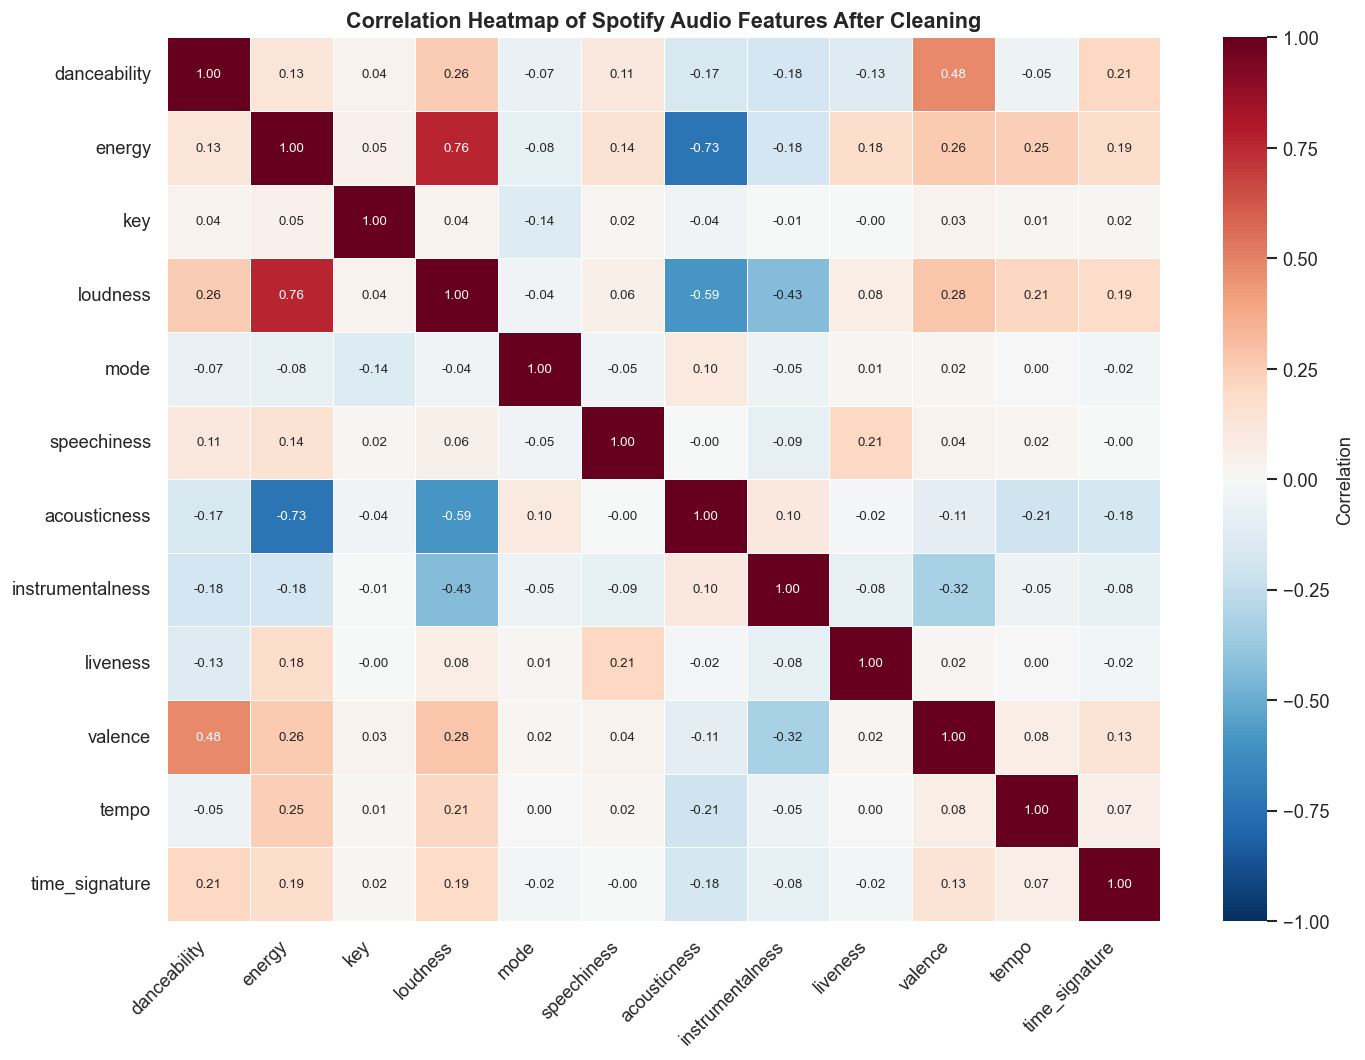

In [24]:
audio_corr = df_clean[spotify_audio_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    audio_corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap of Spotify Audio Features After Cleaning")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
correlation_pairs = []

for i, first_feature in enumerate(spotify_audio_features):
    for second_feature in spotify_audio_features[i + 1:]:
        correlation_pairs.append({
            "feature_1": first_feature,
            "feature_2": second_feature,
            "correlation": audio_corr.loc[first_feature, second_feature]
        })

top_correlations = pd.DataFrame(correlation_pairs)
top_correlations["abs_correlation"] = top_correlations["correlation"].abs()
top_correlations = top_correlations.sort_values("abs_correlation", ascending=False).head(5)
top_correlations = top_correlations.drop(columns="abs_correlation")

top_correlations

,feature_1,feature_2,correlation
12,energy,loudness,0.760624
15,energy,acousticness,-0.732745
32,loudness,acousticness,-0.588110
8,danceability,valence,0.476750
33,loudness,instrumentalness,-0.432108


The strongest relationships are musically intuitive. For example, `energy` and `loudness` are positively correlated, while `energy` and `acousticness` are negatively correlated. We do not remove these features here because the feature set is still small and each variable describes a different musical aspect. Instead, we use this information to understand the data and discuss possible limitations.

### 4.4 Genre-level Audio Patterns

To see whether audio features are useful for genre classification, we compare genre-level averages. This does not train a model; it only checks whether different genres tend to have different audio characteristics.

The table first identifies which genres have the highest and lowest average values for several easy-to-interpret features. Then the heatmap shows a few example genres so that the patterns are easier to read visually.

The six features below are selected for interpretation, not because they are the only useful modeling features. They are easy to explain in a presentation and cover different musical meanings: intensity (`energy`), acoustic style (`acousticness`), rhythm (`danceability`), spoken-word content (`speechiness`), instrumental style (`instrumentalness`), and mood (`valence`). The correlation result in 4.3 helps us understand relationships between features, but this small visualization is mainly for interpretation. Section 5 decides the final modeling feature set separately.

Because the heatmap uses selected example genres and selected interpretable features, it should be read as an illustrative example, not as proof that all 114 genres are easy to separate.

In [26]:
interpretable_features = [
    "energy",
    "acousticness",
    "danceability",
    "speechiness",
    "instrumentalness",
    "valence"
]

genre_feature_means = df_clean.groupby(target_column)[interpretable_features].mean()

top_bottom_rows = []
for feature in interpretable_features:
    highest_genre = genre_feature_means[feature].idxmax()
    lowest_genre = genre_feature_means[feature].idxmin()
    top_bottom_rows.append({
        "feature": feature,
        "highest_genre": highest_genre,
        "highest_mean": round(genre_feature_means.loc[highest_genre, feature], 3),
        "lowest_genre": lowest_genre,
        "lowest_mean": round(genre_feature_means.loc[lowest_genre, feature], 3)
    })

feature_extremes = pd.DataFrame(top_bottom_rows)
feature_extremes

,feature,highest_genre,highest_mean,lowest_genre,lowest_mean
0,energy,death-metal,0.931,classical,0.195
1,acousticness,classical,0.917,death-metal,0.007
2,danceability,kids,0.779,sleep,0.168
3,speechiness,comedy,0.756,honky-tonk,0.037
4,instrumentalness,study,0.789,sertanejo,0.000
5,valence,salsa,0.815,sleep,0.058


The table gives a data-based reason for choosing representative genres in the heatmap below. `classical`, `death-metal`, `sleep`, `comedy`, and `salsa` all come directly from the feature extremes table, so the example selection is easier to explain.

These genres are selected examples for interpretation, not a complete summary of all 114 genres.

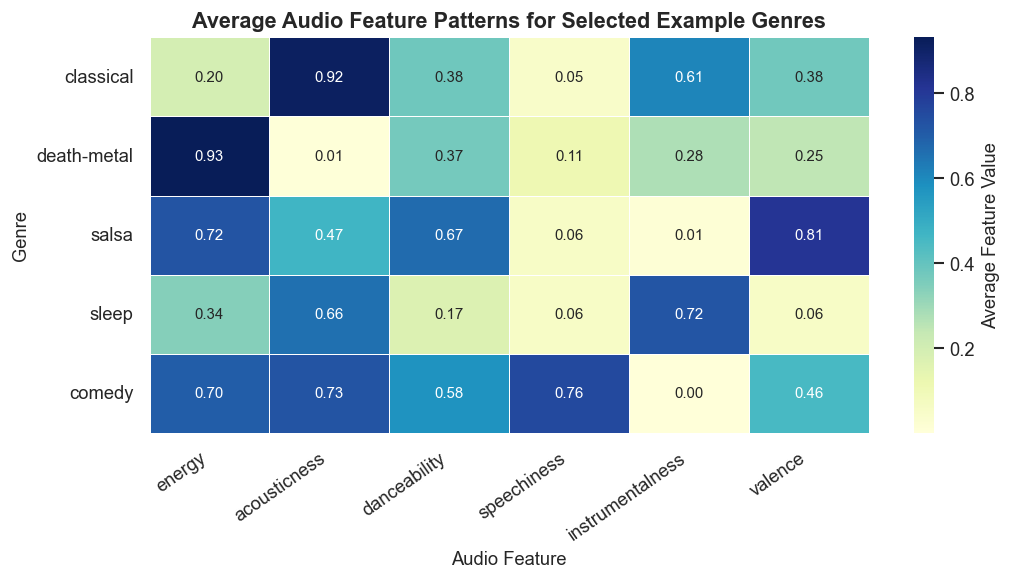

In [27]:
example_genres = [
    "classical",
    "death-metal",
    "salsa",
    "sleep",
    "comedy"
]

example_genre_patterns = genre_feature_means.loc[example_genres]

plt.figure(figsize=(9, 5))
sns.heatmap(
    example_genre_patterns,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Average Feature Value"}
)
plt.title("Average Audio Feature Patterns for Selected Example Genres")
plt.xlabel("Audio Feature")
plt.ylabel("Genre")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

For these selected examples, the audio features show clear and interpretable differences. Each row is one genre, each column is one audio feature, and darker colors mean higher average feature values. For example, `classical` has high acousticness and low energy, `death-metal` has high energy and low acousticness, `comedy` has much higher speechiness, and `salsa` has high valence.

This suggests that audio features may contain useful signals for genre classification. However, this is only an illustrative comparison. Some other genres may be much more similar to each other, so the model may still find the full 114-genre classification task challenging.

### 4.5 EDA Summary

The EDA gives several useful findings:

- After cleaning, the target variable remains relatively balanced across genres.
- Audio features have different distributions, so scaling is useful for distance-based or gradient-based models.
- Some audio features are correlated, especially `energy`, `loudness`, and `acousticness`.
- Selected genre-level examples show meaningful and interpretable differences between some music genres.
- The selected genre-level heatmap is illustrative, not a complete proof that all genres are easy to separate.
- At the same time, the task is still challenging because there are 114 genres, some genres may overlap musically, and some tracks appear under multiple genre labels.

These findings support using Spotify audio features for modeling, while also explaining why genre classification may not be perfect.

## 5. Feature Selection

The goal of this step is to define a clear and explainable feature set for the modeling stage.

This is a rule-based feature selection step based on the project objective, not an algorithmic feature selection method. Based on the project goal, we want to test whether **Spotify audio features** can predict the target variable `track_genre`. Therefore, the selected features should describe the musical characteristics of a track, not its identity or platform popularity.

This section also connects back to the previous analysis:

- Section 3 showed that `track_id` can create leakage, so identity columns must not be used as model features.
- Section 4.2 showed that audio features have different scales and distributions, so Section 6 applies scaling.
- Section 4.3 showed some feature correlations, but correlation alone is not enough reason to remove features.
- Section 4.4 used selected interpretable features only for EDA explanation; it does not define the final modeling feature set.

### 5.1 Selected Feature Set

For the first modeling version, we use the 12 Spotify audio features as the main feature set.

This is a simple and transparent rule-based choice because these variables directly describe musical properties of a song.

In [28]:
selected_features = spotify_audio_features.copy()

selected_feature_table = pd.DataFrame({
    "selected_feature": selected_features,
    "feature_type": [
        "continuous" if feature in continuous_audio_features else "discrete numeric encoding"
        for feature in selected_features
    ]
})

selected_feature_table

,selected_feature,feature_type
0,danceability,continuous
1,energy,continuous
2,key,discrete numeric encoding
3,loudness,continuous
4,mode,discrete numeric encoding
5,speechiness,continuous
6,acousticness,continuous
7,instrumentalness,continuous
8,liveness,continuous
9,valence,continuous


The selected feature set includes both continuous features and discrete numeric encodings.

The discrete features `key`, `mode`, and `time_signature` are kept because they are part of the Spotify audio feature set. However, they should be interpreted carefully because their numeric values represent categories or integer-coded musical information.

### 5.2 Columns Excluded from Modeling

Some columns are useful for understanding the dataset but should not be used as model features for the main task.

In [29]:
feature_decision_table = pd.DataFrame([
    {
        "column_group": "Metadata / identity columns",
        "columns": ", ".join(metadata_columns),
        "decision": "Exclude",
        "reason": "These columns identify the song, artist, album, or track name. They can encourage memorization and do not answer the audio-feature research question."
    },
    {
        "column_group": "Target column",
        "columns": target_column,
        "decision": "Exclude from X, use as y",
        "reason": "This is the label we want to predict, so it must not be included as an input feature."
    },
    {
        "column_group": "Index-like column",
        "columns": ", ".join(index_like_columns),
        "decision": "Already removed",
        "reason": "This column is only an index from the original CSV file and has no modeling meaning."
    },
    {
        "column_group": "Popularity",
        "columns": "popularity",
        "decision": "Exclude from first modeling version",
        "reason": "Popularity is influenced by platform behavior, release timing, and artist visibility, so it is not a pure audio feature."
    },
    {
        "column_group": "Duration",
        "columns": "duration_ms",
        "decision": "Exclude from first modeling version",
        "reason": "Duration describes track length, but the first model focuses on Spotify audio descriptors rather than general track metadata."
    },
    {
        "column_group": "Explicit content flag",
        "columns": "explicit",
        "decision": "Exclude from first modeling version",
        "reason": "This is a lyrical/content flag rather than a musical audio feature."
    }
])

feature_decision_table

,column_group,columns,decision,reason
0,Metadata / identity columns,"track_id, artists, album_name, track_name",Exclude,"These columns identify the song, artist, album..."
1,Target column,track_genre,"Exclude from X, use as y","This is the label we want to predict, so it mu..."
2,Index-like column,Unnamed: 0,Already removed,This column is only an index from the original...
3,Popularity,popularity,Exclude from first modeling version,"Popularity is influenced by platform behavior,..."
4,Duration,duration_ms,Exclude from first modeling version,"Duration describes track length, but the first..."
5,Explicit content flag,explicit,Exclude from first modeling version,This is a lyrical/content flag rather than a m...


### 5.3 Handling Correlated Features

The correlation heatmap showed that some features are related, especially `energy`, `loudness`, and `acousticness`.

However, we do not remove features only based on correlation in this first version because:

1. the number of selected features is still small;
2. each feature has a different musical meaning;
3. correlation shows possible redundancy, but it does not prove that a feature is useless for classification;
4. the final usefulness of the features should be checked through model performance and feature importance analysis during modeling.

Therefore, all 12 Spotify audio features are kept for the first modeling dataset.

### 5.4 Feature Selection Checks

The checks below confirm that the selected feature set is valid and does not include leakage-prone identity columns or the target label.

In [30]:
missing_selected_features = [
    feature for feature in selected_features
    if feature not in df_clean.columns
]

metadata_features_included = [
    feature for feature in selected_features
    if feature in metadata_columns
]

feature_selection_checks = pd.DataFrame([
    {
        "check": "All selected features exist in df_clean",
        "passed": len(missing_selected_features) == 0,
        "details": missing_selected_features if missing_selected_features else "No missing selected features"
    },
    {
        "check": "Target column is not included in selected features",
        "passed": target_column not in selected_features,
        "details": "Target excluded from input features"
    },
    {
        "check": "Metadata columns are not included in selected features",
        "passed": len(metadata_features_included) == 0,
        "details": metadata_features_included if metadata_features_included else "No metadata columns included"
    },
    {
        "check": "Number of selected features",
        "passed": len(selected_features) == 12,
        "details": len(selected_features)
    }
])

feature_selection_checks

,check,passed,details
0,All selected features exist in df_clean,True,No missing selected features
1,Target column is not included in selected feat...,True,Target excluded from input features
2,Metadata columns are not included in selected ...,True,No metadata columns included
3,Number of selected features,True,12


### 5.5 Feature Selection Summary

The final selected feature set for the first modeling stage is:

- `danceability`
- `energy`
- `key`
- `loudness`
- `mode`
- `speechiness`
- `acousticness`
- `instrumentalness`
- `liveness`
- `valence`
- `tempo`
- `time_signature`

These features are selected because they are Spotify audio features and directly match the project goal.

Metadata columns, identity columns, the target column, and non-core audio columns are excluded to keep the model focused on musical audio characteristics and to avoid leakage.

## 6. Data Preparation

This section prepares the modeling dataset using the feature decisions from Section 5 and the leakage findings from Section 3.

The preparation has four parts:

1. create the input matrix `X`, target vector `y`, and grouping variable `groups`;
2. split the data by `track_id` using `GroupShuffleSplit`;
3. verify that the training and test sets do not share the same `track_id` values;
4. scale the selected features using statistics learned only from the training set.

### 6.1 Create X, y, and groups

`X` contains the selected Spotify audio features.  
`y` contains the target label `track_genre`.  
`groups` contains `track_id`, which is used only for grouped splitting and not as a model feature.

In [31]:
X = df_clean[selected_features].copy()
y = df_clean[target_column].copy()
groups = df_clean["track_id"].copy()

model_input_summary = pd.DataFrame({
    "object": ["X", "y", "groups"],
    "meaning": [
        "Selected Spotify audio features",
        "Target genre label",
        "Track ID used for grouped splitting"
    ],
    "rows": [X.shape[0], y.shape[0], groups.shape[0]],
    "columns_or_unique_values": [
        X.shape[1],
        y.nunique(),
        groups.nunique()
    ]
})

model_input_summary

,object,meaning,rows,columns_or_unique_values
0,X,Selected Spotify audio features,113550,12
1,y,Target genre label,113550,114
2,groups,Track ID used for grouped splitting,113550,89741


### 6.2 Grouped Train-Test Split

A normal random split can put the same `track_id` into both training and test data. To avoid this leakage risk, the split is grouped by `track_id`.

With `GroupShuffleSplit`, all rows with the same `track_id` stay on only one side of the split.

This grouped train-test split is used as the fixed final hold-out split for fair model comparison. If validation splits, cross-validation, or repeated tuning are needed during modeling, they should be created only inside the training set and must also be grouped by `track_id`. The test set should stay untouched until final evaluation.

In [32]:
from sklearn.model_selection import GroupShuffleSplit

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_index, test_index = next(group_split.split(X, y, groups=groups))

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()
y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()
groups_train = groups.iloc[train_index].copy()
groups_test = groups.iloc[test_index].copy()

split_shape_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
    "unique_genres": [y_train.nunique(), y_test.nunique()],
    "unique_track_ids": [groups_train.nunique(), groups_test.nunique()]
})

split_shape_summary

,split,rows,features,unique_genres,unique_track_ids
0,train,90973,12,114,71792
1,test,22577,12,114,17949


### 6.3 Check for Track ID Leakage

The most important check is whether any `track_id` appears in both training and test data. The expected result is zero overlapping `track_id` values.

In [33]:
overlapping_track_ids_after_group_split = set(groups_train).intersection(set(groups_test))

group_split_leakage_check = pd.DataFrame({
    "split_method": ["GroupShuffleSplit by track_id"],
    "overlapping_track_ids": [len(overlapping_track_ids_after_group_split)],
    "leakage_check_passed": [len(overlapping_track_ids_after_group_split) == 0]
})

group_split_leakage_check

,split_method,overlapping_track_ids,leakage_check_passed
0,GroupShuffleSplit by track_id,0,True


### 6.4 Check Genre Distribution After Grouped Split

Because the split is grouped by `track_id`, it is important to check whether the genre distribution is still reasonable in both training and test data.

In [34]:
train_genre_counts = y_train.value_counts()
test_genre_counts = y_test.value_counts()

genre_distribution_after_split = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(y_train), len(y_test)],
    "number_of_genres": [train_genre_counts.size, test_genre_counts.size],
    "minimum_rows_per_genre": [train_genre_counts.min(), test_genre_counts.min()],
    "maximum_rows_per_genre": [train_genre_counts.max(), test_genre_counts.max()],
    "average_rows_per_genre": [
        round(train_genre_counts.mean(), 2),
        round(test_genre_counts.mean(), 2)
    ]
})

genre_distribution_after_split

,split,rows,number_of_genres,minimum_rows_per_genre,maximum_rows_per_genre,average_rows_per_genre
0,train,90973,114,721,831,798.01
1,test,22577,114,169,231,198.04


The grouped split keeps all 114 genres in both training and test data. The counts are not perfectly equal because the split is constrained by `track_id`, but the distribution remains suitable for model evaluation.

### 6.5 Scale Selected Features

The selected features have different scales. For example, most features range from 0 to 1, `tempo` is measured in BPM, and `loudness` uses decibels.

To avoid scaling leakage, the scaler is fitted only on `X_train`. The same fitted scaler is then applied to both `X_train` and `X_test`.

In this first simple version, the discrete numeric encodings `key`, `mode`, and `time_signature` are scaled together with the other selected features for consistency. A later modeling version could test one-hot encoding for these variables, especially for models that treat numeric distances strongly.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=selected_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=selected_features,
    index=X_test.index
)

scaled_data_summary = pd.DataFrame({
    "object": ["X_train_scaled", "X_test_scaled"],
    "rows": [X_train_scaled.shape[0], X_test_scaled.shape[0]],
    "features": [X_train_scaled.shape[1], X_test_scaled.shape[1]]
})

scaled_data_summary

,object,rows,features
0,X_train_scaled,90973,12
1,X_test_scaled,22577,12


In [36]:
scaling_check = pd.DataFrame({
    "feature": selected_features,
    "train_mean_after_scaling": X_train_scaled.mean().round(6).values,
    "train_std_after_scaling": X_train_scaled.std(ddof=0).round(6).values
})

scaling_check

,feature,train_mean_after_scaling,train_std_after_scaling
0,danceability,0.0,1.0
1,energy,-0.0,1.0
2,key,-0.0,1.0
3,loudness,-0.0,1.0
4,mode,0.0,1.0
5,speechiness,-0.0,1.0
6,acousticness,-0.0,1.0
7,instrumentalness,-0.0,1.0
8,liveness,0.0,1.0
9,valence,-0.0,1.0


### 6.6 Data Preparation Summary

The prepared data objects are:

- `X_train`, `X_test`: unscaled selected features;
- `X_train_scaled`, `X_test_scaled`: scaled selected features;
- `y_train`, `y_test`: target genre labels;
- `groups_train`, `groups_test`: track IDs used for leakage verification.

The grouped split has zero overlapping `track_id` values between training and test data. The scaler is fitted only on the training data, so the test set remains independent.